In [108]:
import os
import time
import re
import emoji
import pandas as pd
import numpy as np
import pythainlp
from pythainlp.util import normalize
from pythainlp.tokenize import word_tokenize
from pythainlp.corpus.common import thai_stopwords
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.chrome.options import Options
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from webdriver_manager.chrome import ChromeDriverManager
from sklearn.model_selection import (train_test_split, GridSearchCV, StratifiedKFold, cross_val_predict)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (classification_report, accuracy_score, confusion_matrix)
from sklearn.base import clone
from imblearn.over_sampling import SMOTE
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from collections import Counter
import pickle
from nltk.corpus import stopwords as sw

# ดึงข้อมูลจากกระทู้ Pantip

In [ ]:
def scrape_topic(url):
    """
    ดึงข้อมูลจากกระทู้ Pantip
    คืนค่าเป็น DataFrame ที่มีคอลัมน์:
      topic_url, thread_title, tags, author, comment
    โดย:
      - thread_title: หัวข้อกระทู้ (จาก h1, h2 หรือ fallback)
      - tags: ข้อความแท็กของกระทู้ (ดึงจาก element ที่มีคลาส "tag-item")
      - author, comment: ดึงจาก element ที่มีคลาส "display-post-name" และ "display-post-story"
    """
    options = Options()
    options.add_argument("--headless")
    options.add_argument("--no-sandbox")
    options.add_argument("--disable-dev-shm-usage")
    options.add_argument("--disable-gpu")  # เพิ่มเพื่อป้องกันปัญหา GPU
    # ตั้งค่า user-agent ให้เหมือนเบราว์เซอร์จริง
    options.add_argument("user-agent=Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
                         "AppleWebKit/537.36 (KHTML, like Gecko) "
                         "Chrome/115.0.0.0 Safari/537.36")

    service = Service(ChromeDriverManager().install())
    driver = webdriver.Chrome(service=service, options=options)

    # ตั้งค่า Timeout ให้สูงขึ้น
    driver.set_page_load_timeout(60)
    driver.set_script_timeout(60)

    driver.get(url)
    try:
        WebDriverWait(driver, 10).until(
            EC.presence_of_element_located((By.CLASS_NAME, "display-post-story"))
        )
    except Exception as e:
        print(f"[DEBUG] Timeout waiting for comments in {url}: {e}")
    time.sleep(2)

    # ดึงหัวข้อกระทู้: ลองหา h1 ก่อน ถ้าไม่เจอให้หา h2
    try:
        thread_title = driver.find_element(By.TAG_NAME, "h1").text.strip()
    except Exception:
        try:
            thread_title = driver.find_element(By.TAG_NAME, "h2").text.strip()
        except Exception:
            thread_title = ""

    # ดึงแท็กของกระทู้: คาดว่าอยู่ใน element ที่มีคลาส "tag-item"
    try:
        tag_elements = driver.find_elements(By.CLASS_NAME, "tag-item")
        tags = [tag.text.strip() for tag in tag_elements]
    except Exception as e:
        print(f"[DEBUG] ไม่สามารถดึงแท็กได้จาก {url}: {e}")
        tags = []

    # เลื่อนหน้าจอหลายครั้งเพื่อให้โหลดคอมเมนต์ (ลดเวลาการ sleep)
    for _ in range(5):
        driver.execute_script("window.scrollTo(0, document.body.scrollHeight);")
        time.sleep(1)

    try:
        WebDriverWait(driver, 10).until(
            EC.presence_of_all_elements_located((By.CLASS_NAME, "display-post-story"))
        )
    except Exception:
        pass

    # ดึงคอมเมนต์และชื่อผู้โพสต์
    authors = driver.find_elements(By.CLASS_NAME, "display-post-name")
    comments = driver.find_elements(By.CLASS_NAME, "display-post-story")

    print(f"[DEBUG] {url} พบ authors = {len(authors)}, comments = {len(comments)}")

    all_data = []
    for author, comment in zip(authors, comments):
        all_data.append({
            "topic_url": url,
            "thread_title": thread_title,
            "tags": ", ".join(tags),
            "author": author.text.strip(),
            "comment": comment.text.strip()
        })

    driver.quit()
    return pd.DataFrame(all_data)

def main():
    input_csv = "pantip_comments_krungthai.csv"  # ไฟล์ CSV ที่มีลิงก์กระทู้ (คอลัมน์ "topic_url")
    output_csv = "pantip_comments_all_กท.csv"       # ไฟล์สำหรับเก็บข้อมูลที่ดึงได้

    if not os.path.exists(input_csv):
        print(f"ไม่พบไฟล์ {input_csv}")
        return

    df_links = pd.read_csv(input_csv)
    if "topic_url" not in df_links.columns:
        print(f"ไฟล์ {input_csv} ต้องมีคอลัมน์ 'topic_url'")
        return

    # ดึงลิงก์จากคอลัมน์ topic_url ทั้งหมด
    link_list = df_links["topic_url"].dropna().tolist()
    if not link_list:
        print("ไม่พบลิงก์ในไฟล์")
        return

    if os.path.exists(output_csv):
        existing_df = pd.read_csv(output_csv)
    else:
        existing_df = pd.DataFrame(columns=["topic_url", "thread_title", "tags", "author", "comment"])

    new_dfs = []
    # วนลูปดึงข้อมูลจากทุกลิงก์ (จนครบทุกลิงก์)
    for new_url in link_list:
        new_url = new_url.strip()
        if not new_url:
            continue
        print(f"กำลังดึงข้อมูลจาก: {new_url}")
        try:
            df_topic = scrape_topic(new_url)
            new_dfs.append(df_topic)
        except Exception as e:
            print(f"เกิดข้อผิดพลาดในการดึงข้อมูลจาก {new_url}: {e}")

    if new_dfs:
        new_data = pd.concat(new_dfs, ignore_index=True)
    else:
        new_data = pd.DataFrame(columns=["topic_url", "thread_title", "tags", "author", "comment"])

    combined_df = pd.concat([existing_df, new_data], ignore_index=True)

    combined_df["clean_topic_url"] = combined_df["topic_url"].str.strip().str.rstrip("/")
    combined_df.drop_duplicates(subset=["clean_topic_url", "thread_title", "tags", "author", "comment"], inplace=True)

    combined_df.to_csv(output_csv, index=False, encoding="utf-8-sig")

    unique_topics = combined_df["clean_topic_url"].unique()
    print(f"บันทึกข้อมูลลงไฟล์ {output_csv} แล้ว! มีคอมเมนต์ทั้งหมด {len(combined_df)} แถว จาก {len(unique_topics)} กระทู้")

    print("\nตัวอย่างข้อมูลที่ดึงได้:")
    print(combined_df.head())

if __name__ == "__main__":
    main()

# นำเข้าข้อมูล

In [110]:
df = pd.read_csv("test_broker_done.csv", encoding="utf-8-sig", usecols=["topic_url", "thread_title", "author", "comment", "sentiment"])
df

,topic_url,thread_title,author,comment,sentiment
0,https://pantip.com/topic/43014994,แนะนำโบรกเกอร์เทรดหุ้นอเมริกาที่ไม่เสียค่าคอมม...,สมาชิกหมายเลข 3665628,ก่อนอื่นขอบอกก่อนว่าผมไม่ได้ค่าโฆษณา แต่เป็นลู...,บวก
1,https://pantip.com/topic/43037681,มีโบรกเกอร์ไหนสามารถซื้อหุ้น otc ได้บ้างครับ,สมาชิกหมายเลข 1422153,มีโบรกเกอร์ไหนในไทยสามารถซื้อหุ้นจากตลาด otc ไ...,กลาง
2,https://pantip.com/topic/42589290,โบรกเกอร์หุ้นค่ะ,สมาชิกหมายเลข 8036706,ทุกคนคิดว่าโบรคไหนดีคะ ทางนี้กำลังตัดสินใจโบรก...,กลาง
3,https://pantip.com/topic/42589290,โบรกเกอร์หุ้นค่ะ,จะไหวเหรอ,เอ๊กเอ็ม มันโบรกฟอเร็กนิครับ มันไม่น่าจะใช่โบร...,กลาง
4,https://pantip.com/topic/43059564,ขอคำแนะนำออนไลน์โบรกเกอร์หุ้น,parn 256,ถูก มีทั้งหุ้นในประเทศ 0.06 และ หุ้น us 0.10 ม...,กลาง
...,...,...,...,...,...
1322,https://pantip.com/topic/42120119,ซื้อหุ้นแอป innovestX ค่าธรรมเนียมแพงมาก,สมาชิกหมายเลข 2116489,4.99 USD คือ ค่าคอมขั้นต่ำ\n\n\nก็ต้องซื้อหุ้น...,กลาง
1323,https://pantip.com/topic/42120119,ซื้อหุ้นแอป innovestX ค่าธรรมเนียมแพงมาก,สมาชิกหมายเลข 6446669,ซื้อหุ้นนอกค่าธรรมเนียมถูกกว่ามาก\n\nกรณี 5 us...,บวก
1324,https://pantip.com/topic/42120119,ซื้อหุ้นแอป innovestX ค่าธรรมเนียมแพงมาก,สมาชิกหมายเลข 4784008,ส่วนตัวซื้อหุ้นเมกามาตั้งแต่ SCBS จนมาเป็น Inn...,บวก
1325,https://pantip.com/topic/42120119,ซื้อหุ้นแอป innovestX ค่าธรรมเนียมแพงมาก,สมาชิกหมายเลข 7393778,ล่าสุด จขกท. มีอีกช่องทางนึงแล้วคือแอป Dime เป...,บวก


# ทำความสะอาดข้อมูล

In [113]:
# เติมค่าว่างแทน NaN
df['comment'] = df['comment'].fillna('')
# STEP 0: ต้นฉบับ
df['step0_original'] = df['comment']
# STEP 1: demojize
df['step1_demojize'] = df['step0_original'].apply(lambda t: emoji.demojize(t))
# STEP 2: ลบ ? . ; : ! " ๆ ฯ
df['step2_no_punct'] = df['step1_demojize']\
    .apply(lambda t: "".join(ch for ch in t if ch not in ("?",".",";",":","!",'"',"ๆ","ฯ")))
# STEP 3: ลบ URL (http/https/www)
df['step3_no_url'] = df['step2_no_punct']\
    .apply(lambda t: re.sub(r'https?://\S+|www\.\S+', ' ', t))
# STEP 4: ลบ mention @username
df['step4_no_mention'] = df['step3_no_url']\
    .apply(lambda t: re.sub(r'@\w+', ' ', t))
# STEP 5: เก็บแค่ ก-๙, A-Za-z, 0-9, space
df['step5_alnum'] = df['step4_no_mention']\
    .apply(lambda t: re.sub(r'[^ก-๙A-Za-z0-9\s]', ' ', t))
# STEP 6: เว้นวรรคทุกตัวอักษร
df['step6_char_spaced'] = df['step5_alnum']\
    .apply(lambda t: " ".join(t))
# STEP 7: ลบ stopwords ไทย (ระดับอักขระ)
thai_stops = set(thai_stopwords())
df['step7_no_thai_stop'] = df['step6_char_spaced']\
    .apply(lambda t: "".join(ch for ch in t.split() if ch not in thai_stops))
# STEP 8: ตัดคำด้วย newmm
df['step8_tokenized'] = df['step7_no_thai_stop']\
    .apply(lambda t: pythainlp.word_tokenize(t, engine='newmm'))
# STEP 9: join tokens กลับเป็นสตริง
df['step9_joined'] = df['step8_tokenized']\
    .apply(lambda toks: " ".join(toks))
# STEP 10: ลบอักขระที่เกิน pattern สุดท้าย
df['comment_clean'] = df['step9_joined']\
    .apply(lambda t: re.sub(r'[^A-Za-zก-๙]+', ' ', t).strip())
print("ตัวอย่างข้อความที่ผ่านการทำความสะอาด:")
df

ตัวอย่างข้อความที่ผ่านการทำความสะอาด:


,topic_url,thread_title,author,comment,sentiment,step0_original,step1_demojize,step2_no_punct,step3_no_url,step4_no_mention,step5_alnum,step6_char_spaced,step7_no_thai_stop,step8_tokenized,step9_joined,comment_clean
0,https://pantip.com/topic/43014994,แนะนำโบรกเกอร์เทรดหุ้นอเมริกาที่ไม่เสียค่าคอมม...,สมาชิกหมายเลข 3665628,ก่อนอื่นขอบอกก่อนว่าผมไม่ได้ค่าโฆษณา แต่เป็นลู...,บวก,ก่อนอื่นขอบอกก่อนว่าผมไม่ได้ค่าโฆษณา แต่เป็นลู...,ก่อนอื่นขอบอกก่อนว่าผมไม่ได้ค่าโฆษณา แต่เป็นลู...,ก่อนอื่นขอบอกก่อนว่าผมไม่ได้ค่าโฆษณา แต่เป็นลู...,ก่อนอื่นขอบอกก่อนว่าผมไม่ได้ค่าโฆษณา แต่เป็นลู...,ก่อนอื่นขอบอกก่อนว่าผมไม่ได้ค่าโฆษณา แต่เป็นลู...,ก่อนอื่นขอบอกก่อนว่าผมไม่ได้ค่าโฆษณา แต่เป็นลู...,ก ่ อ น อ ื ่ น ข อ บ อ ก ก ่ อ น ว ่ า ผ ม ไ ...,ก่อนอื่นขอบอกก่อนว่าผมไม่ได้ค่าโฆษาแต่เป็นลูกค...,"[ก่อนอื่น, ขอ, บอก, ก่อน, ว่า, ผม, ไม่, ได้, ค...",ก่อนอื่น ขอ บอก ก่อน ว่า ผม ไม่ ได้ ค่า โฆษา แ...,ก่อนอื่น ขอ บอก ก่อน ว่า ผม ไม่ ได้ ค่า โฆษา แ...
1,https://pantip.com/topic/43037681,มีโบรกเกอร์ไหนสามารถซื้อหุ้น otc ได้บ้างครับ,สมาชิกหมายเลข 1422153,มีโบรกเกอร์ไหนในไทยสามารถซื้อหุ้นจากตลาด otc ไ...,กลาง,มีโบรกเกอร์ไหนในไทยสามารถซื้อหุ้นจากตลาด otc ไ...,มีโบรกเกอร์ไหนในไทยสามารถซื้อหุ้นจากตลาด otc ไ...,มีโบรกเกอร์ไหนในไทยสามารถซื้อหุ้นจากตลาด otc ไ...,มีโบรกเกอร์ไหนในไทยสามารถซื้อหุ้นจากตลาด otc ไ...,มีโบรกเกอร์ไหนในไทยสามารถซื้อหุ้นจากตลาด otc ไ...,มีโบรกเกอร์ไหนในไทยสามารถซื้อหุ้นจากตลาด otc ไ...,ม ี โ บ ร ก เ ก อ ร ์ ไ ห น ใ น ไ ท ย ส า ม า ...,มีโบรกเกอร์ไหนในไทยสามารถซื้อหุ้นจากตลาดotcได้...,"[มี, โบรกเกอร์, ไหน, ใน, ไทย, สามารถ, ซื้อ, หุ...",มี โบรกเกอร์ ไหน ใน ไทย สามารถ ซื้อ หุ้น จาก ต...,มี โบรกเกอร์ ไหน ใน ไทย สามารถ ซื้อ หุ้น จาก ต...
2,https://pantip.com/topic/42589290,โบรกเกอร์หุ้นค่ะ,สมาชิกหมายเลข 8036706,ทุกคนคิดว่าโบรคไหนดีคะ ทางนี้กำลังตัดสินใจโบรก...,กลาง,ทุกคนคิดว่าโบรคไหนดีคะ ทางนี้กำลังตัดสินใจโบรก...,ทุกคนคิดว่าโบรคไหนดีคะ ทางนี้กำลังตัดสินใจโบรก...,ทุกคนคิดว่าโบรคไหนดีคะ ทางนี้กำลังตัดสินใจโบรก...,ทุกคนคิดว่าโบรคไหนดีคะ ทางนี้กำลังตัดสินใจโบรก...,ทุกคนคิดว่าโบรคไหนดีคะ ทางนี้กำลังตัดสินใจโบรก...,ทุกคนคิดว่าโบรคไหนดีคะ ทางนี้กำลังตัดสินใจโบรก...,ท ุ ก ค น ค ิ ด ว ่ า โ บ ร ค ไ ห น ด ี ค ะ ...,ทุกคนคิดว่าโบรคไหนดีคะทางนี้กำลังตัดสินใจโบรกx...,"[ทุกคน, คิด, ว่า, โบ, รค, ไหน, ดี, คะ, ทาง, นี...",ทุกคน คิด ว่า โบ รค ไหน ดี คะ ทาง นี้ กำลัง ตั...,ทุกคน คิด ว่า โบ รค ไหน ดี คะ ทาง นี้ กำลัง ตั...
3,https://pantip.com/topic/42589290,โบรกเกอร์หุ้นค่ะ,จะไหวเหรอ,เอ๊กเอ็ม มันโบรกฟอเร็กนิครับ มันไม่น่าจะใช่โบร...,กลาง,เอ๊กเอ็ม มันโบรกฟอเร็กนิครับ มันไม่น่าจะใช่โบร...,เอ๊กเอ็ม มันโบรกฟอเร็กนิครับ มันไม่น่าจะใช่โบร...,เอ๊กเอ็ม มันโบรกฟอเร็กนิครับ มันไม่น่าจะใช่โบร...,เอ๊กเอ็ม มันโบรกฟอเร็กนิครับ มันไม่น่าจะใช่โบร...,เอ๊กเอ็ม มันโบรกฟอเร็กนิครับ มันไม่น่าจะใช่โบร...,เอ๊กเอ็ม มันโบรกฟอเร็กนิครับ มันไม่น่าจะใช่โบร...,เ อ ๊ ก เ อ ็ ม ม ั น โ บ ร ก ฟ อ เ ร ็ ก น ...,เอ๊กเอ็มมันโบรกฟอเร็กนิครับมันไม่น่าจะใช่โบรกเ...,"[เอ๊, ก, เอ็ม, มัน, โบรก, ฟอ, เร็ก, นิ, ครับ, ...",เอ๊ ก เอ็ม มัน โบรก ฟอ เร็ก นิ ครับ มัน ไม่ น่...,เอ๊ ก เอ็ม มัน โบรก ฟอ เร็ก นิ ครับ มัน ไม่ น่...
4,https://pantip.com/topic/43059564,ขอคำแนะนำออนไลน์โบรกเกอร์หุ้น,parn 256,ถูก มีทั้งหุ้นในประเทศ 0.06 และ หุ้น us 0.10 ม...,กลาง,ถูก มีทั้งหุ้นในประเทศ 0.06 และ หุ้น us 0.10 ม...,ถูก มีทั้งหุ้นในประเทศ 0.06 และ หุ้น us 0.10 ม...,ถูก มีทั้งหุ้นในประเทศ 006 และ หุ้น us 010 มั้...,ถูก มีทั้งหุ้นในประเทศ 006 และ หุ้น us 010 มั้...,ถูก มีทั้งหุ้นในประเทศ 006 และ หุ้น us 010 มั้...,ถูก มีทั้งหุ้นในประเทศ 006 และ หุ้น us 010 มั้...,ถ ู ก ม ี ท ั ้ ง ห ุ ้ น ใ น ป ร ะ เ ท ศ ...,ถูกมีทั้งหุ้นในประเทศ006และหุ้นus010มั้งถ้าจำไ...,"[ถูก, มี, ทั้ง, หุ้น, ในประเทศ, 006, และ, หุ้น...",ถูก มี ทั้ง หุ้น ในประเทศ 006 และ หุ้น us 010 ...,ถูก มี ทั้ง หุ้น ในประเทศ และ หุ้น us มั้ง ถ้า...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1322,https://pantip.com/topic/42120119,ซื้อหุ้นแอป innovestX ค่าธรรมเนียมแพงมาก,สมาชิกหมายเลข 2116489,4.99 USD คือ ค่าคอมขั้นต่ำ\n\n\nก็ต้องซื้อหุ้น...,กลาง,4.99 USD คือ ค่าคอมขั้นต่ำ\n\n\nก็ต้องซื้อหุ้น...,4.99 USD คือ ค่าคอมขั้นต่ำ\n\n\nก็ต้องซื้อหุ้น...,499 USD ค

In [114]:
print(df['comment'].head(10))

0    ก่อนอื่นขอบอกก่อนว่าผมไม่ได้ค่าโฆษณา แต่เป็นลู...
1    มีโบรกเกอร์ไหนในไทยสามารถซื้อหุ้นจากตลาด otc ไ...
2    ทุกคนคิดว่าโบรคไหนดีคะ ทางนี้กำลังตัดสินใจโบรก...
3    เอ๊กเอ็ม มันโบรกฟอเร็กนิครับ มันไม่น่าจะใช่โบร...
4    ถูก มีทั้งหุ้นในประเทศ 0.06 และ หุ้น us 0.10 ม...
5    รีวิวจากคนใช้งานจริง\n1. InnovestX\nบัญชีเงินส...
6    ย้ายไป sbito ถึงราคาหุ้นจะถัวเฉลี่ยกัน แต่เวลา...
7    โบรกเกอร์ไหนซื้อหุ้นฮ่องกงแบบเศษหุ้นได้บ้าง  ซ...
8    ในกรณีที่โบรกเกอร์ปิดตัวลง เราสามารถติดตามหุ้น...
9    คงต้องติดตามโดยตรงกับตลาดหลักทรัพย์ของประเทศ ท...
Name: comment, dtype: object


In [115]:
print(df['comment_clean'].head(10))

0    ก่อนอื่น ขอ บอก ก่อน ว่า ผม ไม่ ได้ ค่า โฆษา แ...
1    มี โบรกเกอร์ ไหน ใน ไทย สามารถ ซื้อ หุ้น จาก ต...
2    ทุกคน คิด ว่า โบ รค ไหน ดี คะ ทาง นี้ กำลัง ตั...
3    เอ๊ ก เอ็ม มัน โบรก ฟอ เร็ก นิ ครับ มัน ไม่ น่...
4    ถูก มี ทั้ง หุ้น ในประเทศ และ หุ้น us มั้ง ถ้า...
5    รีวิว จาก คน ใช้งาน จริง InnovestX บัญชีเงินสด...
6    ย้าย ไป sbito ถึง ราคา หุ้น จะ ถัวเฉลี่ย กัน แ...
7    โบรกเกอร์ ไหน ซื้อ หุ้น ฮ่องกง แบบ เศษ หุ้น ได...
8    ใน กรี ที่ โบรกเกอร์ ปิด ตัว ลง เรา สามารถ ติด...
9    คง ต้อง ติดตาม โดยตรง กับ ตลาดหลักทรัพย์ ของ ป...
Name: comment_clean, dtype: object


# wordcloud

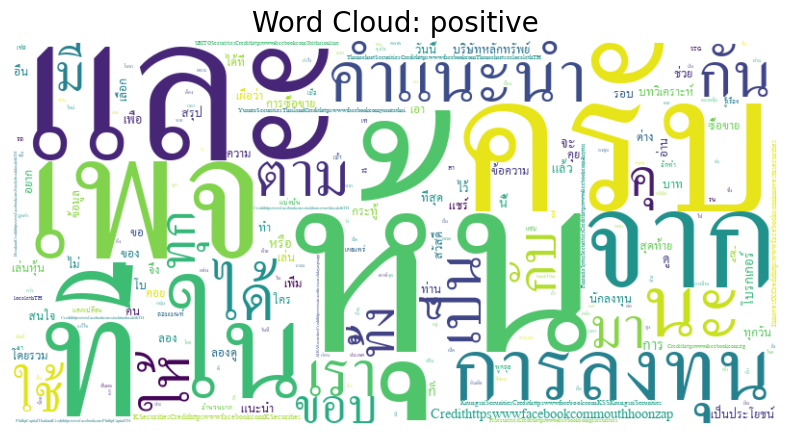

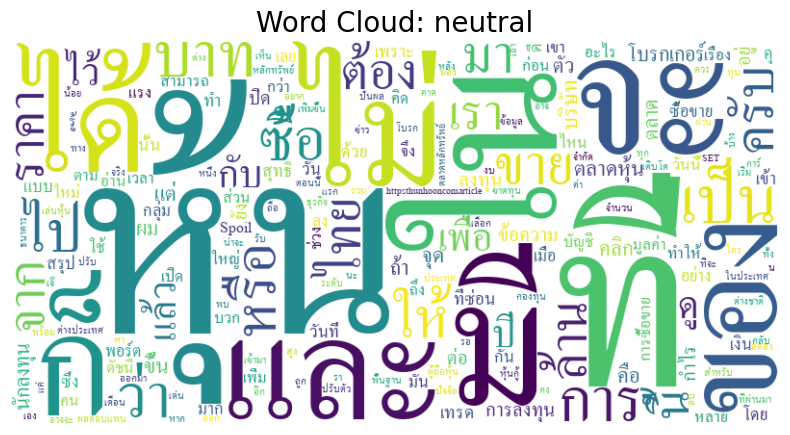

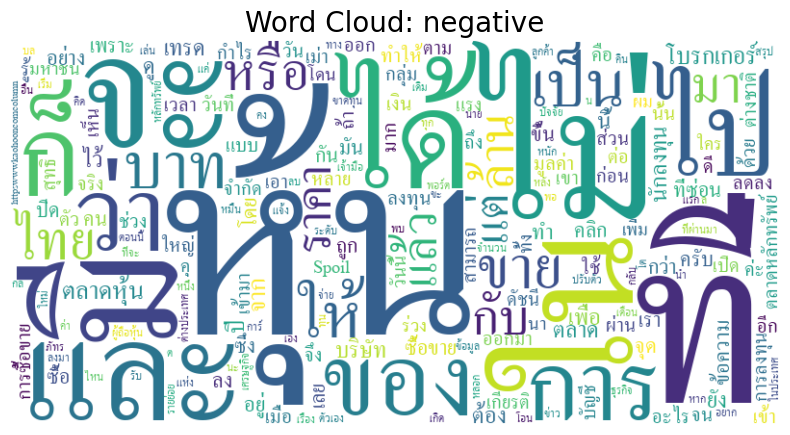

In [117]:
mapping = {'บวก':'positive', 'กลาง':'neutral', 'ลบ':'negative'}
df['sentiment'] = df['sentiment'].replace(mapping)

thai_fonts = [f for f in fm.findSystemFonts() 
              if any(n in os.path.basename(f).lower() for n in ['thsarabun','leelawadee','angsana'])]
font_path = thai_fonts[0]

def plot_wordcloud_from_freq(freq_dict, title):
    wc = WordCloud(
        font_path=font_path,
        width=800, height=400,
        background_color='white',
        collocations=False
    ).generate_from_frequencies(freq_dict)
    plt.figure(figsize=(10,5))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(title, fontsize=20)
    plt.show()

# --- เตรียม Counter สำหรับแต่ละคลาส ---
for label in ['positive','neutral','negative']:
    # 1) เก็บ list ของคำแต่ละข้อความ
    words = []
    for doc in df.loc[df['sentiment']==label, 'comment_clean']:
        # แยกตาม space (แต่ละ doc ต้องผ่านการ tokenized มาแล้ว)
        words.extend(doc.split())
    # 2) สร้างความถี่
    freq = Counter(words)
    # 3) plot
    plot_wordcloud_from_freq(freq, f"Word Cloud: {label}")


# แบ่งกลุ่มข้อมูล
จำแนก pseudo category เป็น 6 หมวด:
1. เทคนิคและระบบ (Technical Issues)
2. ค่าธรรมเนียม (Fees)
3. การบริการ (Service Quality)
4. การเทรด (Trading Experience)
5. รีวิว/คำแนะนำ (Review/Advice)
6. อื่นๆ (Other)

In [119]:
technical_keywords = {"ระบบล่ม", "ช้า", "error", "บัค", "ปัญหา", "เชื่อมต่อ"}
fee_keywords = {"ค่าสมัคร", "ค่าธรรมเนียม", "คอมมิชชั่น", "สเปรด", "spread"}
service_keywords = {"บริการ", "ลูกค้าสัมพันธ์", "ซัพพอร์ต", "ช่วยเหลือ", "แพลตฟอร์ม", "แอป", "สอบถาม","แจ้ง","ข้อมูล","มือถือ", "ฝาก", "ถอน", }
trading_keywords = {"เทรด", "ซื้อขาย", "หุ้น", "order", "execution", "เลเวอเรจ", "trade", "brokerage", "ราคา","พอร์ต","ปริมาณ","สัญญาณ", "ตลท", "ตลาดหลักทรัพย์", "forex", "โอนหลักทรัพย์"}
review_keywords = {"แนะนำ", "รีวิว", "ข้อเสนอแนะ", "คำแนะนำ","โปรโมชั่น","วิเคราะห์","ข้อเสนอ", "เลือก", "ดู", "แนะนำ"}

# ----- ส่วนที่ 2: ฟังก์ชันจำแนกหมวดหมู่เบื้องต้น -----
def assign_category(text):
    text_lower = str(text).lower()
    if any(kw.lower() in text_lower for kw in technical_keywords):
        return "ระบบ"
    elif any(kw.lower() in text_lower for kw in fee_keywords):
        return "ค่าธรรมเนียม"
    elif any(kw.lower() in text_lower for kw in service_keywords):
        return "การบริการ"
    elif any(kw.lower() in text_lower for kw in trading_keywords):
        return "การเทรด"
    elif any(kw.lower() in text_lower for kw in review_keywords):
        return "รีวิว/คำแนะนำ"
    else:
        return "อื่นๆ"

# ----- ส่วนที่ 3: สร้าง pseudo labels -----
df['pseudo_category'] = df['comment_clean'].apply(assign_category)

# ----- ส่วนที่ 4: แปลง labels เป็นตัวเลข -----
le = LabelEncoder()
y_cat_encoded = le.fit_transform(df['pseudo_category'])

# ----- ส่วนที่ 5: แปลงข้อความเป็น TF-IDF features -----
tfidf_vectorizer_cat = TfidfVectorizer()
X_cat = tfidf_vectorizer_cat.fit_transform(df['comment_clean'])

# ----- ตรวจสอบผลลัพธ์ -----
print("การกระจาย pseudo_category:")
print(df['pseudo_category'].value_counts())
print(f"\nขนาดเมทริกซ์ features: {X_cat.shape}")
print(f"จำนวน labels: {len(y_cat_encoded)}")

การกระจาย pseudo_category:
pseudo_category
การเทรด         823
การบริการ       377
ระบบ             87
ค่าธรรมเนียม     38
อื่นๆ             2
Name: count, dtype: int64

ขนาดเมทริกซ์ features: (1327, 6231)
จำนวน labels: 1327


In [120]:
others = df[df['pseudo_category']=='อื่นๆ']['comment'].reset_index(drop=True)
print("คอมเมนต์ที่ยังเป็น 'อื่นๆ':")
for i, txt in enumerate(others,1):
    print(f"{i}. {txt}")


คอมเมนต์ที่ยังเป็น 'อื่นๆ':
1. อะไรมันจะเปลี่ยนไปได้ขนาดนี้ครับแต่คนที่เป็นโบรกเกอร์ผมไม่เคยเห็นครับ(หรือมีหว่า)เคยเห็นแต่มาร์ที่ทำงานในโบรกเกอร์ครับ
2. DRX สภาพคล่องทุเรศมากกินสเปรด สเปรดห่างกันบางตัว 5-7 ช่อง สุดท้ายไปลงทุนเองเหมือนเดิม


# สุ่มทำข้อมูลให้เท่ากัน

In [122]:
df_positive = df[df['sentiment'] == 'positive']
df_negative = df[df['sentiment'] == 'negative']
df_neutral = df[df['sentiment'] == 'neutral']

# Calculate the minimum count among all sentiment categories
min_count = min(len(df_positive), len(df_negative), len(df_neutral))

# Sample from each category using the minimum count
df_negative_balanced = df_negative.sample(n=min_count, replace=False, random_state=42)  # Added replace=False and random_state for reproducibility
df_neutral_balanced = df_neutral.sample(n=min_count, replace=False, random_state=42)
df_positive_balanced = df_positive.sample(n=min_count, replace=False, random_state=42)  # Sample from df_positive as well

# Concatenate the balanced DataFrames
df_model = pd.concat([df_positive_balanced, df_negative_balanced, df_neutral_balanced]).reset_index(drop=True)
print("จำนวนตัวอย่าง:", len(df_model))
print(df_model['sentiment'].value_counts())

จำนวนตัวอย่าง: 909
sentiment
positive    303
negative    303
neutral     303
Name: count, dtype: int64


In [123]:
df_model

,topic_url,thread_title,author,comment,sentiment,step0_original,step1_demojize,step2_no_punct,step3_no_url,step4_no_mention,step5_alnum,step6_char_spaced,step7_no_thai_stop,step8_tokenized,step9_joined,comment_clean,pseudo_category
0,https://pantip.com/topic/42650722,การบ้านหุ้นจากกูรู 18/4/2567,สมาชิกหมายเลข 7683991,คำแนะนำหุ้นจากเพจการลงทุน 5 เพจ\n\n1. เม...,positive,คำแนะนำหุ้นจากเพจการลงทุน 5 เพจ\n\n1. เม...,คำแนะนำหุ้นจากเพจการลงทุน 5 เพจ\n\n1. เม...,คำแนะนำหุ้นจากเพจการลงทุน 5 เพจ\n\n1 เม้...,คำแนะนำหุ้นจากเพจการลงทุน 5 เพจ\n\n1 เม้...,คำแนะนำหุ้นจากเพจการลงทุน 5 เพจ\n\n1 เม้...,คำแนะนำหุ้นจากเพจการลงทุน 5 เพจ\n\n1 เม้...,ค ำ แ น ะ น ำ ห ุ ้ น จ า ก เ พ จ ก า ร ล ง ท ...,คำแนะนำหุ้นจากเพจการลงทุน5เพจ1เม้าหุ้นแซ่บCred...,"[คำแนะนำ, หุ้น, จาก, เพจ, การลงทุน, 5, เพจ, 1,...",คำแนะนำ หุ้น จาก เพจ การลงทุน 5 เพจ 1 เม้า หุ้...,คำแนะนำ หุ้น จาก เพจ การลงทุน เพจ เม้า หุ้น แซ...,การบริการ
1,https://pantip.com/topic/43052731,฿฿฿฿฿ คุยโขมงห้องค้าหุ้นไทย@สินธร ประจำวันอังค...,restart,Wealthy Thai\nรายการโปรด ? 33 นาที ?\n3 หุ้น...,positive,Wealthy Thai\nรายการโปรด ? 33 นาที ?\n3 หุ้น...,Wealthy Thai\nรายการโปรด ? 33 นาที ?\n3 หุ้น...,Wealthy Thai\nรายการโปรด 33 นาที \n3 หุ้นตั...,Wealthy Thai\nรายการโปรด 33 นาที \n3 หุ้นตั...,Wealthy Thai\nรายการโปรด 33 นาที \n3 หุ้นตั...,Wealthy Thai\nรายการโปรด 33 นาที \n3 หุ้นตั...,W e a l t h y T h a i \n ร า ย ก า ร โ ป ร ด...,WealthyThaiรายการโปรด33นาที3หุ้นตัวเต็งเหมาะเก...,"[WealthyThai, รายการ, โปรด, 33, นาที, 3, หุ้น,...",WealthyThai รายการ โปรด 33 นาที 3 หุ้น ตัวเต็ง...,WealthyThai รายการ โปรด นาที หุ้น ตัวเต็ง เหมา...,การเทรด
2,https://pantip.com/topic/42770621,การบ้านหุ้นจากกูรู 10/6/2567,สมาชิกหมายเลข 7683991,สวัสดีครับ เราเป็นคนที่คอยตามอ่านบทวิเคราะห์แล...,positive,สวัสดีครับ เราเป็นคนที่คอยตามอ่านบทวิเคราะห์แล...,สวัสดีครับ เราเป็นคนที่คอยตามอ่านบทวิเคราะห์แล...,สวัสดีครับ เราเป็นคนที่คอยตามอ่านบทวิเคราะห์แล...,สวัสดีครับ เราเป็นคนที่คอยตามอ่านบทวิเคราะห์แล...,สวัสดีครับ เราเป็นคนที่คอยตามอ่านบทวิเคราะห์แล...,สวัสดีครับ เราเป็นคนที่คอยตามอ่านบทวิเคราะห์แล...,ส ว ั ส ด ี ค ร ั บ เ ร า เ ป ็ น ค น ท ี ่ ...,สวัสดีครับเราเป็นคนที่คอยตามอ่านบทวิเคราะห์และ...,"[สวัสดี, ครับ, เรา, เป็น, คน, ที่, คอย, ตาม, อ...",สวัสดี ครับ เรา เป็น คน ที่ คอย ตาม อ่าน บทวิเ...,สวัสดี ครับ เรา เป็น คน ที่ คอย ตาม อ่าน บทวิเ...,การเทรด
3,https://pantip.com/topic/42715356,การบ้านหุ้นจากกูรู 17/5/2567,สมาชิกหมายเลข 7683991,คำแนะนำหุ้นจากเพจการลงทุน 5 เพจ\n\n1. เม...,positive,คำแนะนำหุ้นจากเพจการลงทุน 5 เพจ\n\n1. เม...,คำแนะนำหุ้นจากเพจการลงทุน 5 เพจ\n\n1. เม...,คำแนะนำหุ้นจากเพจการลงทุน 5 เพจ\n\n1 เม้...,คำแนะนำหุ้นจากเพจการลงทุน 5 เพจ\n\n1 เม้...,คำแนะนำหุ้นจากเพจการลงทุน 5 เพจ\n\n1 เม้...,คำแนะนำหุ้นจากเพจการลงทุน 5 เพจ\n\n1 เม้...,ค ำ แ น ะ น ำ ห ุ ้ น จ า ก เ พ จ ก า ร ล ง ท ...,คำแนะนำหุ้นจากเพจการลงทุน5เพจ1เม้าหุ้นแซ่บCred...,"[คำแนะนำ, หุ้น, จาก, เพจ, การลงทุน, 5, เพจ, 1,...",คำแนะนำ หุ้น จาก เพจ การลงทุน 5 เพจ 1 เม้า หุ้...,คำแนะนำ หุ้น จาก เพจ การลงทุน เพจ เม้า หุ้น แซ...,การบริการ
4,https://pantip.com/topic/42191430,การบ้านหุ้นจากกูรู 28/8/66,สมาชิกหมายเลข 7683991,สวัสดีครับ เราเป็นคนที่คอยตามอ่านบทวิเคราะห์แล...,positive,สวัสดีครับ เราเป็นคนที่คอยตามอ่านบทวิเคราะห์แล...,สวัสดีครับ เราเป็นคนที่คอยตามอ่านบทวิเคราะห์แล...,สวัสดีครับ เราเป็นคนที่คอยตามอ่านบทวิเคราะห์แล...,สวัสดีครับ เราเป็นคนที่คอยตามอ่านบทวิเคราะห์แล...,สวัสดีครับ เราเป็นคนที่คอยตามอ่านบทวิเคราะห์แล...,สวัสดีครับ เราเป็นคนที่คอยตามอ่านบทวิเคราะห์แล...,ส ว ั ส ด ี ค ร ั บ เ ร า เ ป ็ น ค น ท ี ่ ...,สวัสดีครับเราเป็นคนที่คอยตามอ่านบทวิเคราะห์และ...,"[สวัสดี, ครับ, เรา, เป็น, คน, ที่, คอย, ตาม, อ...",สวัสดี ครับ เรา เป็น คน ที่ คอย ตาม อ่าน บทวิเ...,สวัสดี ครับ เรา เป็น คน ที่ คอย ตาม อ่าน บทวิเ...,การเทรด
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
904,https://pantip.com/topic/42486298,เพื่อนสามีเป็นอัมพาตก่อนป่วยจะเล่นหุ้น มีเงินใ...,จะดูแลเธอตลอดไป,ถ้ารู้รหัสพิน Streaming และ บัญชีออมทรัพย์ ATS...,neutral,ถ้ารู้รหัสพิน Streaming และ บัญชีออมทรัพย์ ATS...,ถ้ารู้รหัสพิน Streaming และ บัญชีออมทรัพย์ ATS...,ถ้า

# TF-IDF

In [125]:
X = df_model['comment_clean']
y = df_model['sentiment']

le = LabelEncoder()
y_encoded = le.fit_transform(y)
print("Sentiment classes :", le.classes_)
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2)
print("Training samples:", X_train.shape[0], "Test samples:", X_test.shape[0])
tfidf_vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1,3))
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)
print("Vocabulary Size (TF-IDF):", len(tfidf_vectorizer.vocabulary_))

Sentiment classes : ['negative' 'neutral' 'positive']
Training samples: 727 Test samples: 182
Vocabulary Size (TF-IDF): 5000


In [126]:
print("Shape of TF-IDF matrix (Training):", X_train_tfidf.shape)

Shape of TF-IDF matrix (Training): (727, 5000)


In [127]:
print(X_train_tfidf[:10])

  (0, 4887)	0.09639394089434473
  (0, 2475)	0.1021401561138447
  (0, 3104)	0.085822095334274
  (0, 3362)	0.0990264997985043
  (0, 2712)	0.07763202842017786
  (0, 3267)	0.08867501637587473
  (0, 3095)	0.08867501637587473
  (0, 2439)	0.10595096345881581
  (0, 1830)	0.0833782436396778
  (0, 3781)	0.1021401561138447
  (0, 4615)	0.0990264997985043
  (0, 4298)	0.09210203613819279
  (0, 4886)	0.0709808158485308
  (0, 2406)	0.08227606583110508
  (0, 2474)	0.09030270729998932
  (0, 3311)	0.085822095334274
  (0, 3103)	0.0833782436396778
  (0, 4329)	0.07846525848613398
  (0, 3424)	0.0990264997985043
  (0, 2387)	0.09030270729998932
  (0, 3802)	0.09210203613819279
  (0, 2790)	0.09030270729998932
  (0, 3361)	0.09210203613819279
  (0, 1015)	0.09411351464496046
  (0, 1260)	0.07607842797539821
  :	:
  (8, 4739)	0.058344192366099334
  (8, 2897)	0.07174801948641735
  (8, 3241)	0.07823693138053948
  (8, 3066)	0.11958003247736224
  (8, 983)	0.04718589263225287
  (8, 530)	0.0258119708249708
  (8, 3899)	0.02

In [128]:
# 1) Vectorizer แบบ split-on-space (clean_comment ต้องมี space คั่นคำเต็มแล้ว)
vectorizer = TfidfVectorizer(
    tokenizer=lambda doc: doc.split(),
    preprocessor=None,
    token_pattern=None,
    lowercase=False,
    max_features=5000
)
X = vectorizer.fit_transform(df_model['comment_clean'])
feature_names = vectorizer.get_feature_names_out()

# 2) ฟังก์ชันดึง top‑N TF‑IDF terms ของ doc ใดๆ
def top_tfidf_terms(row_vector, features, top_n=10):
    # row_vector: 1×n array
    coefs = row_vector.toarray().ravel()
    # ดัชนีของ Top‑N
    topn_ids = coefs.argsort()[-top_n:][::-1]
    return [(features[i], coefs[i]) for i in topn_ids if len(features[i])>2]  # กรองคำสั้นๆ

# 3) ลองดู Top‑10 คำจากเอกสารตัวอย่างแถวที่ 0
terms = top_tfidf_terms(X[1], feature_names, top_n=10)
df_terms = pd.DataFrame(terms, columns=['token','tfidf_weight'])
print("Top‑10 TF‑IDF terms for document #0:")
print(df_terms)

Top‑10 TF‑IDF terms for document #0:
     token  tfidf_weight
0      SET      0.300031
1     ลุ้น      0.264978
2      คาด      0.233681
3  เข้าออก      0.226538
4  รายชื่อ      0.208716
5    ครึ่ง      0.194329
6   ได้แก่      0.192361
7     เข้า      0.179179
8      แรก      0.153525


# model

In [130]:
lasso_logistic = LogisticRegression(penalty='l1', solver='saga', max_iter=6000)
param_grid = {"C": [0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000]}
skf = StratifiedKFold(n_splits=10, shuffle=True,)

grid = GridSearchCV(lasso_logistic, param_grid, cv=skf, scoring='f1_macro', n_jobs=-1)
grid.fit(X_train_tfidf, y_train)
print("\nLasso Logistic Regression ")
print("Best Parameters:", grid.best_params_)
print("Best CV F1_macro Score:", grid.best_score_)
best_model = grid.best_estimator_


Lasso Logistic Regression 
Best Parameters: {'C': 10}
Best CV F1_macro Score: 0.7066857507232427


In [131]:
best_model.coef_

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [132]:
non_zero_features = np.sum(best_model.coef_ != 0)
print( non_zero_features)

421


In [133]:
X_full = tfidf_vectorizer.transform(df_model['comment_clean'])
y_full = le.transform(df_model['sentiment'])

skf_full = StratifiedKFold(n_splits=10, shuffle=True)
fold = 1
accuracy_list = []

for train_idx, test_idx in skf_full.split(X_full, y_full):
    X_cv_train = X_full[train_idx]
    y_cv_train = y_full[train_idx]
    X_cv_test  = X_full[test_idx]
    y_cv_test  = y_full[test_idx]
    
    # ใช้ clone เพื่อสร้างสำเนาของโมเดลที่ดีที่สุดสำหรับแต่ละ fold
    model_cv = clone(best_model)
    model_cv.fit(X_cv_train, y_cv_train)
    y_cv_pred = model_cv.predict(X_cv_test)
    acc_fold = accuracy_score(y_cv_test, y_cv_pred)
    print(f"Fold {fold} Accuracy: {acc_fold:.4f}")
    accuracy_list.append(acc_fold)
    fold += 1

mean_accuracy = np.mean(accuracy_list)
print("\nMean CV Accuracy (Loop):", mean_accuracy)

Fold 1 Accuracy: 0.7033
Fold 2 Accuracy: 0.7692
Fold 3 Accuracy: 0.7692
Fold 4 Accuracy: 0.7363
Fold 5 Accuracy: 0.7582
Fold 6 Accuracy: 0.7143
Fold 7 Accuracy: 0.7253
Fold 8 Accuracy: 0.7253
Fold 9 Accuracy: 0.7143
Fold 10 Accuracy: 0.7556

Mean CV Accuracy (Loop): 0.7370940170940171


In [134]:
y_pred = best_model.predict(X_test_tfidf)
acc = accuracy_score(y_test, y_pred)
print("\nTest Accuracy:", acc)
print("\nClassification Report on Test Set:")
print(classification_report(y_test, y_pred, target_names=le.classes_, zero_division=0))
print("Confusion Matrix on Test Set:")
print(confusion_matrix(y_test, y_pred))


Test Accuracy: 0.7307692307692307

Classification Report on Test Set:
              precision    recall  f1-score   support

    negative       0.64      0.71      0.67        49
     neutral       0.66      0.68      0.67        66
    positive       0.90      0.79      0.84        67

    accuracy                           0.73       182
   macro avg       0.73      0.73      0.73       182
weighted avg       0.74      0.73      0.73       182

Confusion Matrix on Test Set:
[[35 13  1]
 [16 45  5]
 [ 4 10 53]]


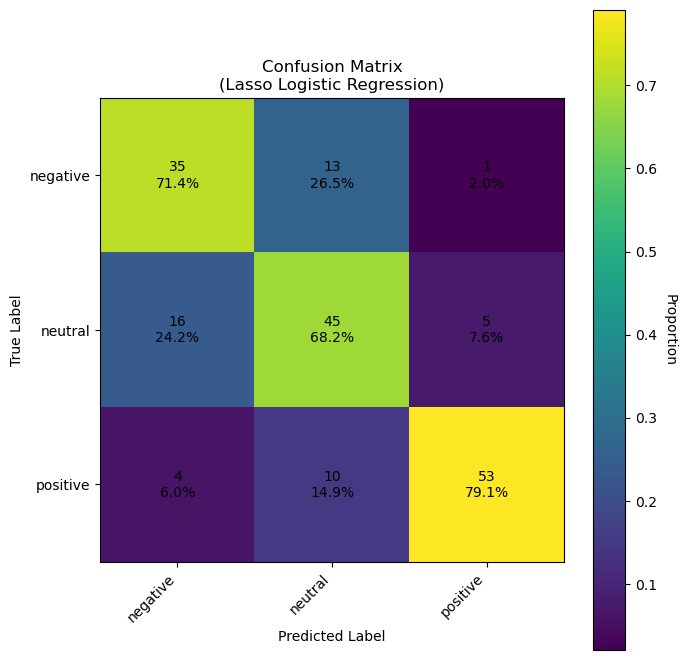

In [135]:
cm = confusion_matrix(y_test, y_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
classes = le.classes_

fig, ax = plt.subplots(figsize=(7,7))
im = ax.imshow(cm_norm, interpolation='nearest')

cbar = fig.colorbar(im, ax=ax)
cbar.ax.set_ylabel('Proportion', rotation=-90, va="bottom")

ax.set_xticks(np.arange(len(classes)))
ax.set_yticks(np.arange(len(classes)))
ax.set_xticklabels(classes)
ax.set_yticklabels(classes)
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

for i in range(len(classes)):
    for j in range(len(classes)):
        count = cm[i, j]
        pct = cm_norm[i, j] * 100
        ax.text(j, i, f"{count}\n{pct:.1f}%", 
                ha="center", va="center")

ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
ax.set_title('Confusion Matrix\n(Lasso Logistic Regression)')
plt.tight_layout()
plt.show()


In [136]:
best_model.fit(tfidf_vectorizer.transform(df_model['comment_clean']), le.transform(df_model['sentiment']))
df_model['predicted_sentiment'] = best_model.predict(tfidf_vectorizer.transform(df_model['comment_clean']))
df_model['predicted_sentiment'] = le.inverse_transform(df_model['predicted_sentiment'])
print(df_model['predicted_sentiment'].value_counts())

predicted_sentiment
neutral     304
negative    303
positive    302
Name: count, dtype: int64


In [140]:
df_model.to_csv('sentiment_broker.csv', encoding="utf-8-sig")

In [141]:
def preprocess_text(text):
    if pd.isnull(text):
        return ''
    text = emoji.demojize(text)
    text = "".join(u for u in text if u not in ("?", ".", ";", ":", "!", '"', "ๆ", "ฯ"))
    text = re.sub(r'https?://\S+|www\.\S+', ' ', text)
    text = re.sub(r'@\w+', ' ', text)
    text = re.sub(r'[^ก-๙A-Za-z0-9\s]', ' ', text)
    text = " ".join(word for word in text)
    text = "".join(word for word in text.split() if word.lower() not in thai_stopwords())
    tokens = pythainlp.word_tokenize(str(text), engine='newmm')
    text = " ".join(tokens)
    text = re.sub('[^A-Za-zก-๙]+', ' ', text).strip()
    return text


In [142]:
import numpy as np

# ข้อความตัวอย่างใหม่
new_text = 'ดีค่าธรรมเนียมถูกระบบฝากถอนรวดเร็ว'

# ทำความสะอาด
clean = preprocess_text(new_text)
print("Cleaned :", clean)

# แปลงเป็น TF-IDF
X_new = tfidf_vectorizer.transform([clean])

# ทำนายความน่าจะเป็นแต่ละคลาส
probs = best_model.predict_proba(X_new)[0]
print("Probabilities:", dict(zip(le.classes_, probs.round(3))))

# เลือก sentiment ที่มีความน่าจะเป็นสูงสุด
idx  = np.argmax(probs)
sent = le.inverse_transform([idx])[0]
conf = probs[idx]
print(f'Predicted Sentiment: {sent} ({conf*100:.2f}% confidence)')


Cleaned : ดี ค่าธรรมเนียม ถูก ระบบ ฝาก ถอน รวดเร็ว
Probabilities: {'negative': 0.027, 'neutral': 0.026, 'positive': 0.946}
Predicted Sentiment: positive (94.61% confidence)


In [148]:
import numpy as np

# ข้อความตัวอย่างใหม่
new_text = 'แย่ แพง '

# ทำความสะอาด
clean = preprocess_text(new_text)
print("Cleaned :", clean)

# แปลงเป็น TF-IDF
X_new = tfidf_vectorizer.transform([clean])

# ทำนายความน่าจะเป็นแต่ละคลาส
probs = best_model.predict_proba(X_new)[0]
print("Probabilities:", dict(zip(le.classes_, probs.round(3))))

# เลือก sentiment ที่มีความน่าจะเป็นสูงสุด
idx  = np.argmax(probs)
sent = le.inverse_transform([idx])[0]
conf = probs[idx]
print(f'Predicted Sentiment: {sent} ({conf*100:.2f}% confidence)')


Cleaned : แย่ แพง
Probabilities: {'negative': 0.983, 'neutral': 0.016, 'positive': 0.001}
Predicted Sentiment: negative (98.30% confidence)


In [152]:
import numpy as np

# ข้อความตัวอย่างใหม่
new_text = 'เฉยๆ'

# ทำความสะอาด
clean = preprocess_text(new_text)
print("Cleaned :", clean)

# แปลงเป็น TF-IDF
X_new = tfidf_vectorizer.transform([clean])

# ทำนายความน่าจะเป็นแต่ละคลาส
probs = best_model.predict_proba(X_new)[0]
print("Probabilities:", dict(zip(le.classes_, probs.round(3))))

# เลือก sentiment ที่มีความน่าจะเป็นสูงสุด
idx  = np.argmax(probs)
sent = le.inverse_transform([idx])[0]
conf = probs[idx]
print(f'Predicted Sentiment: {sent} ({conf*100:.2f}% confidence)')

Cleaned : เฉย
Probabilities: {'negative': 0.243, 'neutral': 0.7, 'positive': 0.057}
Predicted Sentiment: neutral (70.02% confidence)
